# Difference in Normalized Burn Ratio (dNBR) for Fire Area Detection using OpenEO

This notebook demonstrates how to detect the burned area in a forest fire using Sentinel-2 miagery. The burned area is identifyed based on the difference in normalized burn ratio. A pre and a post fire image are loaded and the dNBR is calculated for each of them and then subtracted.

# Overview

1. Import libraries, define parameters and connect to OpenEO backend
2. Load pre and post fire satellite image
3. Calculate and visualize dNBR 
4. Failed Approaches to load and index both images in one cube

## 1. Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import openeo
from openeo.processes import array_create, if_, and_
from openeo.api.process import Parameter
# OpenEO UDP parameter management system
from openeo_udp import ParameterManager
import rasterio

### Define Parameters and Connect to OpenEO Backend

Load algorithm parameters from the co-located parameter file and connect to an OpenEO backend with automatic endpoint selection.
Choose between CDE and EOPF

In [ ]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

fire_date = 2025 # 2024 or 2025

if fire_date == 2025:
    time_post= ["2025-10-15", "2025-10-16"]
    time_pre = ["2025-07-25", "2025-07-31"]

    current_params = {
            "location_name": "Forest, North Portugal",
            "bounding_box": Parameter(
                "bounding_box",
                description="Fire area in 2025",
                default= {"west": -7.987061, "south": 40.012891, "east": -7.434998,"north": 40.359103}
    ),
            "time": Parameter(
                "time",
                description="Temporal range for data acquisition",
                # default=["2025-10-15", "2025-10-16"], # + last
                default=["2025-07-25", "2025-07-31"],  # + last
            ),
            "bands": Parameter(
                "bands",
                description="Sentinel-2 bands required for APA calculation",
                default=["B8A", "B12"]
    #,
            ),
            "collection": Parameter(
                "collection",
                description="Data collection identifier",
                default="SENTINEL2_L2A",
            ),
            "cloud_cover": Parameter(
                "cloud_cover",
                description="Maximum cloud cover percentage",
                default=30,
            ),
        }


if fire_date == 2024:
    
    time_post= ["2024-09-30", "2024-10-15"] # + last
    time_pre=  ["2024-08-20", "2024-09-01"]  # + last

    current_params = {
            "location_name": "Reriz e Gafanhao, North Portugal",
            "bounding_box": Parameter(
                "bounding_box",
                description="Fire area in 2024",
                default= {"west": -8.23, "south": 40.76, "east": -7.78, "north": 41}
    ),
            "time": Parameter(
                "time",
                description="Temporal range for data acquisition",
                # default=["2024-09-30", "2024-10-30"], # + last
                default=["2024-08-01", "2024-09-01"],  # + last
            ),
            "bands": Parameter(
                "bands",
                description="Sentinel-2 bands required for APA calculation",
                default=["B8A", "B12"]
    #,
            ),
            "collection": Parameter(
                "collection",
                description="Data collection identifier",
                default="SENTINEL2_L2A",
            ),
            "cloud_cover": Parameter(
                "cloud_cover",
                description="Maximum cloud cover percentage",
                default=30,
            ),
        }





Authenticated using refresh token.


## 2. Load Image before and after the fire as seperate cubes



In [ ]:
# First define functions to use for loading image and calculating NBR

def load_and_sample(params, time, res=100):
    """
    Input: Set of parameters, time frame, desired resolution
    Output: Cube that contains the last image in the time frame 
    """ 
    s2cube = connection.load_collection(
    params["collection"].default,
    temporal_extent=time,
    spatial_extent=params["bounding_box"].default,
    bands=params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= params["cloud_cover"].default,
    },
    )

    s2cube = s2cube.reduce_dimension(dimension="t", reducer="last")

    s2cube = s2cube.resample_spatial(
        resolution=[res, res],
      method="near",
    )

    return s2cube
    

def calculate_nbr(data):
     """ 
     Input: Cube with bands 08 and 12
     Output: NBR
     """
     B08, B12 = (
          data[0],
          data[1],
     )
     nbr = (B08 - B12) / (B08 + B12)
     return nbr

In [63]:

# Define Resolution
res_dnbr = 20

# Load Satellite image before and after the fire as cubes
s2cube_pre = load_and_sample(current_params, time_pre, res_dnbr)
s2cube_post = load_and_sample(current_params, time_post, res_dnbr)

In [64]:
# Calculate NBR of pre and post cube
nbr_post = s2cube_post.reduce_dimension(dimension="bands", reducer=calculate_nbr)
nbr_pre = s2cube_pre.reduce_dimension(dimension="bands", reducer=calculate_nbr)

## 3. Calculate dNBR by subtracting between the cubes

In [65]:
#Using CDE either of these three work

dnbr = nbr_pre - nbr_post

# from openeo.processes import subtract
# dnbr = nbr_pre.subtract(nbr_post)


# dnbr = nbr_pre.merge_cubes(nbr_post, overlap_resolver="subtract")

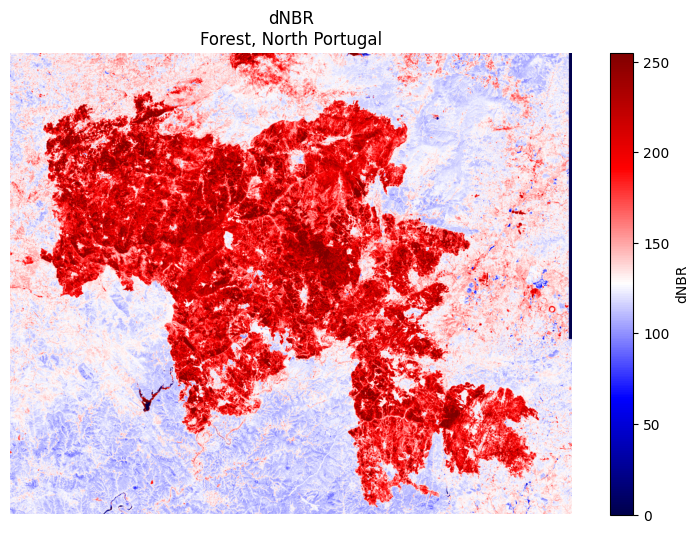

In [66]:
# Download and visualize dNBR
dnbr_vis = dnbr.linear_scale_range(-1, 1, 0, 255)
dnbr_png = dnbr_vis.save_result("PNG")

filename = f"apa_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.png"

connection.download(
{
    "process_graph": dnbr_png.flat_graph(),
},
filename,
)

dnbr_img = Image.open(filename)
plt.figure(figsize=(10, 6))
plt.imshow(dnbr_img, cmap="seismic", vmin=0, vmax=255)
plt.colorbar(label="dNBR")
plt.title(f"dNBR\n{current_params['location_name']}")
plt.axis("off")
plt.show()

### Make mask of burned area with threshold


In [42]:
# Define Threshold and filter to only include points where dNBR is larger than threshold
burn_treshold = 0.3
dnbr_mask = (dnbr > burn_treshold)


mask_vis = dnbr_mask.linear_scale_range(-1, 1, 0, 255)
mask_png = mask_vis.save_result("PNG")


filename_mask = f"firemask_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.png"

connection.download(
{
    "process_graph": mask_png.flat_graph(),
},
filename_mask,)

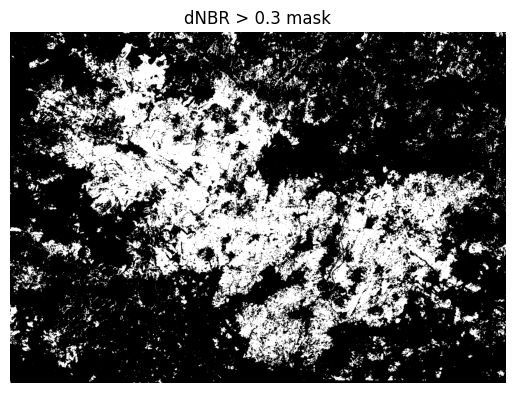

In [43]:
dnbr_mask_img = Image.open(filename_mask)
plt.imshow(dnbr_mask_img, cmap='grey')
plt.title(f"dNBR > {burn_treshold} mask")
plt.axis("off")
plt.show()

In [44]:
#This is patchy, so lets try a filter::

dnbr_smooth = dnbr.apply_kernel([
    [1,1,1],
    [1,1,1],
    [1,1,1]
]) / 9


burn_treshold = 0.3
dnbr_mask = (dnbr_smooth > burn_treshold)


mask_vis = dnbr_mask.linear_scale_range(-1, 1, 0, 255)
mask_png_smooth = mask_vis.save_result("PNG")


filename_mask_smooth = f"firemask_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.png"

connection.download(
{
    "process_graph": mask_png_smooth.flat_graph(),
},
filename_mask,)

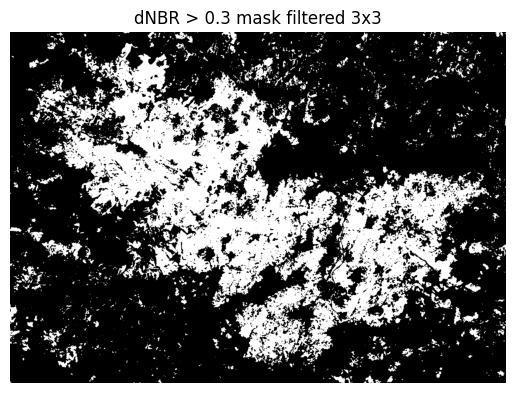

In [45]:
dnbr_mask_img = Image.open(filename_mask)
plt.imshow(dnbr_mask_img, cmap='grey')
plt.title(f"dNBR > {burn_treshold} mask filtered 3x3")
plt.axis("off")
plt.show()

## 4. Approach 2: Load Both images in one cube

In [27]:
s2cube_both = connection.load_collection(
    "SENTINEL2_L2A",
    temporal_extent=["2025-07-25", "2025-10-16"],  # full range
    spatial_extent=current_params["bounding_box"].default,
    bands=current_params["bands"].default,
)
s2cube_both = s2cube_both.resample_spatial(resolution=[100, 100], method="near")

# Apply NBR to get time series
nbr_timeseries = s2cube_both.apply_dimension(dimension="bands", process=calculate_nbr)

#### Custom Reducer - Return dnbr
I would like to index nbr_timeseries [0] and [-1] (first and last element to perform calculation)
However, this seems to fail because I can not index -1, is there another way for me to find the last element?

In [28]:
def dnbr_reducer(data):
    # data is the time series of NBR values
    first_nbr = data[0]
    last_nbr = data[-1]
    dnbr =  first_nbr - last_nbr
    return dnbr

# Reduce time dimension with your custom reducer (returns single image)
dnbr = nbr_timeseries.reduce_dimension(dimension="t", reducer=dnbr_reducer)

In [29]:
test(dnbr)

OpenEoApiError: [500] Internal: Server error: Exception during Spark execution: java.lang.IndexOutOfBoundsException: -1 is out of bounds (min 0, max 24) (ref: r-2606181015144c988b92cc5b4ff40aa1)

Testing if this works for first and second image

In [ ]:
def dnbr_reducer(data):
    # data is the time series of NBR values
    first_nbr = data[0]
    second_nbr = data[1]
    dnbr =  first_nbr - second_nbr
    return dnbr

# Reduce time dimension with your custom reducer (returns single image)
dnbr = nbr_timeseries.reduce_dimension(dimension="time", reducer=dnbr_reducer)


In [ ]:
test(dnbr)

OpenEoApiError: [500] ServerError: index 1 is out of bounds for axis 0 with size 1